## 

In [243]:
"""
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_country(model, df, country_name, fixed_features, enc_len=100, forecast_len=30):
    total_len = enc_len + forecast_len

                                                                                                           # Slice country
    g = df[df['Country'] == country_name].sort_values('time_step').reset_index(drop=True)
    if len(g) < total_len:
        print(f"Not enough data for {country_name}")
        return None

    x_fixed = torch.tensor(g[fixed_features].iloc[0].values.astype(np.float32)).unsqueeze(0)
    true_seq = g['cumulative_norm'].iloc[:total_len].values

    with torch.no_grad():
        pred_seq = model(x_fixed).squeeze(0).cpu().numpy()

                                                                                                                 # Split
    true_train = true_seq[:enc_len]
    true_forecast = true_seq[enc_len:total_len]
    pred_train = pred_seq[:enc_len]
    pred_forecast = pred_seq[enc_len:total_len]

                                                                                                               # Metrics
    metrics = {
        "train_mse": mean_squared_error(true_train, pred_train),
        "train_r2": r2_score(true_train, pred_train),
        "forecast_mse": mean_squared_error(true_forecast, pred_forecast),
        "forecast_r2": r2_score(true_forecast, pred_forecast),
    }

    return metrics
"""

In [244]:
"""
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_country(model, df, country_name, fixed_features, enc_len=100, forecast_len=30):
    total_len = enc_len + forecast_len

    # Get country data
    g = df[df['Country'] == country_name].sort_values('time_step').reset_index(drop=True)
    if len(g) < total_len:
        print(f"Not enough data for {country_name}")
        return None

    # Fixed features (only once per country)
    x_fixed = torch.tensor(g[fixed_features].iloc[0].values.astype(np.float32)).unsqueeze(0)

    # Ground truth
    true_seq = g['cumulative_norm'].iloc[:total_len].values

    # Prediction
    with torch.no_grad():
        pred_seq = model(x_fixed).squeeze(0).cpu().numpy()

    # Split train vs forecast
    true_train, true_forecast = true_seq[:enc_len], true_seq[enc_len:total_len]
    pred_train, pred_forecast = pred_seq[:enc_len], pred_seq[enc_len:total_len]

    # --- Training error ---
    train_mse = mean_squared_error(true_train, pred_train)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(true_train, pred_train)

    # --- Forecast error ---
    test_mse = mean_squared_error(true_forecast, pred_forecast)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(true_forecast, pred_forecast)

    # Collect results
    metrics = {
        "country": country_name,
        "train_mse": train_mse, "train_rmse": train_rmse, "train_mae": train_mae,
        "test_mse": test_mse,   "test_rmse": test_rmse,   "test_mae": test_mae
    }

    return metrics
"""

Epoch 100/2000 | Train Loss: 0.038097 | Forecast Loss: 0.036292
Epoch 200/2000 | Train Loss: 0.008909 | Forecast Loss: 0.014214
Epoch 300/2000 | Train Loss: 0.004600 | Forecast Loss: 0.003107
Epoch 400/2000 | Train Loss: 0.002203 | Forecast Loss: 0.001834
Epoch 500/2000 | Train Loss: 0.002319 | Forecast Loss: 0.002291
Epoch 600/2000 | Train Loss: 0.001493 | Forecast Loss: 0.001402
Epoch 700/2000 | Train Loss: 0.001263 | Forecast Loss: 0.000860
Epoch 800/2000 | Train Loss: 0.000998 | Forecast Loss: 0.000774
Epoch 900/2000 | Train Loss: 0.000797 | Forecast Loss: 0.000557
Epoch 1000/2000 | Train Loss: 0.000727 | Forecast Loss: 0.000608
Epoch 1100/2000 | Train Loss: 0.000570 | Forecast Loss: 0.000434
Epoch 1200/2000 | Train Loss: 0.000381 | Forecast Loss: 0.000304
Epoch 1300/2000 | Train Loss: 0.000295 | Forecast Loss: 0.000125
Epoch 1400/2000 | Train Loss: 0.000243 | Forecast Loss: 0.000118
Epoch 1500/2000 | Train Loss: 0.000202 | Forecast Loss: 0.000065
Epoch 1600/2000 | Train Loss: 0.00

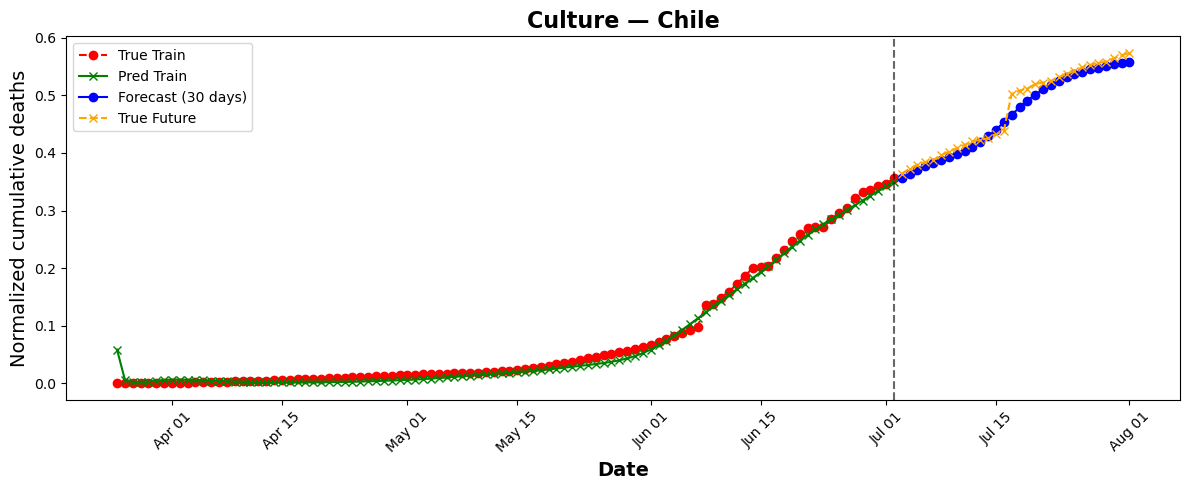

In [202]:
"""
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.dates as mdates

# -----------------------
# 1) Load + preprocess
# -----------------------
path = "Merged_1.csv"
df = pd.read_csv(path)

df = df.drop(['country_region', 'date.1'], axis=1, errors='ignore')
df = df.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'TotalDeaths',
    'date': 'Date',
    'individualism': 'Individualism',
    'masculinity': 'Masculinity',
    'powerdistance': 'Power Distance',
    'uncertaintyavoidance': 'Uncertainty Avoidance',
    'longtermorientation': 'Long Term Orientation',
    'democracyindex2021': 'Democracy Index',
    'indulgence': 'Indulgence',
    'gdp_per_capita': 'GDP (per capita)',
    'aged_65_older': 'Aged 65 Older',
    'stringency_index': 'Stringency Index',
    'population': 'Population'
})

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)
df['time_step'] = df.groupby('Country').cumcount()

# fixed features (you can add more if you want)
fixed_features = [
    'Individualism','Masculinity','Power Distance','Indulgence',
    'Uncertainty Avoidance','Long Term Orientation'
]

df[fixed_features] = StandardScaler().fit_transform(df[fixed_features])

# Target normalization
df['TotalDeaths'] = df['TotalDeaths'].fillna(0)
daily = df.groupby('Country')['TotalDeaths'].diff().fillna(0).clip(lower=0)
df['CumulativeDeaths'] = daily.groupby(df['Country']).cumsum()
df['cumulative_norm'] = df.groupby('Country')['CumulativeDeaths'].transform(
    lambda x: x / (x.max() if x.max() > 0 else 1.0)
)

# -----------------------
# 2) Dataset
# -----------------------
ENC_LEN = 100
FORECAST_LEN = 30
TOTAL_LEN = ENC_LEN + FORECAST_LEN

class CountryFixedDataset(Dataset):
    def __init__(self, df, total_len=115):
        self.total_len = total_len
        self.groups = []
        for country, g in df.groupby('Country'):
            g = g.sort_values('time_step').reset_index(drop=True)
            if len(g) >= total_len:
                self.groups.append((country, g))
        self.fixed_cols = fixed_features
        self.target_col = 'cumulative_norm'

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        country, g = self.groups[idx]
        x_fixed = g[self.fixed_cols].iloc[0].values.astype(np.float32)
        y = g[self.target_col].iloc[:self.total_len].values.astype(np.float32)
        return torch.tensor(x_fixed), torch.tensor(y), country



# 3) LSTM Model

class FixedLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, seq_len, num_layers=1):
        super().__init__()
        self.seq_len = seq_len
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x_fixed):
        # replicate fixed features over all time steps
        batch_size = x_fixed.size(0)
        x_seq = x_fixed.unsqueeze(1).repeat(1, self.seq_len, 1)  # [batch, seq_len, input_dim]
        out, _ = self.lstm(x_seq)
        out = self.fc(out).squeeze(-1)  # [batch, seq_len]
        return torch.sigmoid(out)



# 4) Train function



def train_model(model, loader, epochs=2000, lr=1e-3, clip=1.0, verbose_every=100,
                enc_len=100, total_len=130):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0.0
        total_forecast_loss = 0.0

        for x_fixed, y, _ in loader:
            x_fixed, y = x_fixed.to(device), y.to(device)
            pred = model(x_fixed)

            # Split predictions and targets
            pred_train = pred[:, :enc_len]
            pred_forecast = pred[:, enc_len:total_len]
            y_train = y[:, :enc_len]
            y_forecast = y[:, enc_len:total_len]

            # Separate losses
            loss_train = loss_fn(pred_train, y_train)
            loss_forecast = loss_fn(pred_forecast, y_forecast)
            loss_total = loss_train + loss_forecast  # total loss for backprop

            opt.zero_grad()
            loss_total.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()

            total_train_loss += loss_train.item()
            total_forecast_loss += loss_forecast.item()

        if epoch % verbose_every == 0:
            print(f"Epoch {epoch}/{epochs} | "
                  f"Train Loss: {total_train_loss / len(loader):.6f} | "
                  f"Forecast Loss: {total_forecast_loss / len(loader):.6f}")

    return model

# -----------------------
# 5) Train model
# -----------------------

dataset = CountryFixedDataset(df, total_len=TOTAL_LEN)
loader = DataLoader(dataset, batch_size=50, shuffle=False)

model = FixedLSTM(input_dim=len(fixed_features), hidden_dim= 256, seq_len=TOTAL_LEN)
model = train_model(model, loader, epochs=2000, lr=1e-3, clip=1.0, verbose_every=100)


# -----------------------
# 6) Forecast one country
# -----------------------
country_name = "Chile"
g = df[df['Country'] == country_name].sort_values('time_step').reset_index(drop=True)
x_fixed = torch.tensor(g[fixed_features].iloc[0].values.astype(np.float32)).unsqueeze(0)
true_seq = g['cumulative_norm'].iloc[:TOTAL_LEN].values

with torch.no_grad():
    pred_seq = model(x_fixed).squeeze(0).cpu().numpy()

pred_train = pred_seq[:ENC_LEN]
pred_forecast = pred_seq[ENC_LEN:TOTAL_LEN]
true_train = true_seq[:ENC_LEN]
true_forecast = true_seq[ENC_LEN:TOTAL_LEN]

# -----------------------
# 7) Plot
# -----------------------
plt.figure(figsize=(12, 5))
dates = pd.to_datetime(g['Date'].iloc[:TOTAL_LEN])

plt.plot(dates[:ENC_LEN], true_train, 'o--', label="True Train", color='red')
plt.plot(dates[:ENC_LEN], pred_train, 'x-', label="Pred Train", color='green')
plt.plot(dates[ENC_LEN:TOTAL_LEN], pred_forecast, 'o-', label="Forecast (30 days)", color='blue')

if len(true_forecast) == FORECAST_LEN:
    plt.plot(dates[ENC_LEN:TOTAL_LEN], true_forecast, 'x--', label="True Future", color='orange')

plt.axvline(dates.iloc[ENC_LEN - 1], color='k', linestyle='--', alpha=0.6)
plt.title(f"Culture — {country_name}", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Normalized cumulative deaths", fontsize=14)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
"""

In [55]:
"""
from sklearn.preprocessing import MinMaxScaler
"""

In [56]:
""""
df['daily_deaths'] = df['TotalDeaths'].diff().clip(lower=0)
"""

In [57]:
"""
scaler = MinMaxScaler()
series = scaler.fit_transform(df['daily_deaths'].values.reshape(-1,1))
"""

In [60]:
"""
df['daily'] = df['TotalDeaths'].diff().fillna(0)
values = scaler.fit_transform(df['daily'].values.reshape(-1,1))
"""

In [61]:
"""
df['TotalDeaths'] = df['TotalDeaths'].fillna(0)

# daily deaths
df['daily_deaths'] = df.groupby('Country')['TotalDeaths'].diff().fillna(0).clip(lower=0)

# compute country max for normalization
country_scale = df.groupby('Country')['TotalDeaths'].transform('max').replace(0,1)

df['daily_norm'] = df['daily_deaths'] / country_scale
df['cumulative_norm'] = df.groupby('Country')['daily_norm'].cumsum()
"""

In [62]:
"""
class TimeSeriesDataset(Dataset):
    def __init__(self, df, dynamic_cols, static_cols, enc_len=100, forecast_len=30):
        self.enc_len = enc_len
        self.forecast_len = forecast_len
        self.total_len = enc_len + forecast_len
        self.samples = []
        
        for country, g in df.groupby("Country"):
            g = g.sort_values("Date").reset_index(drop=True)
            
            if len(g) >= self.total_len:
                dyn = g[dynamic_cols].values.astype(np.float32)
                stat = g[static_cols].iloc[0].values.astype(np.float32)

                # TARGET = DAILY normalized deaths
                y = g["daily_norm"].values.astype(np.float32)

                self.samples.append((dyn, stat, y, country))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        dyn, stat, y, country = self.samples[idx]
        
        x_dyn = dyn[:self.enc_len]         
        x_static = stat                   
        
        y_full = y[:self.total_len]        # daily_norm, 130 steps
        
        return torch.tensor(x_dyn), torch.tensor(x_static), torch.tensor(y_full), country
"""

In [63]:
"""
def forecast_country(model, g, dynamic_cols, static_cols, enc_len=100, forecast_len=30):
    model.eval()
    device = next(model.parameters()).device
    
    dyn = torch.tensor(g[dynamic_cols].values[:enc_len]).unsqueeze(0).float().to(device)
    stat = torch.tensor(g[static_cols].iloc[0].values).unsqueeze(0).float().to(device)

    x_dyn = dyn.clone()
    preds = []

    with torch.no_grad():
        for _ in range(forecast_len):
            out = model(x_dyn, stat)[:, -1].item()     # predict daily_norm
            preds.append(out)

            next_dyn = x_dyn[:, -1, :].clone()
            next_dyn[0, 0] = out                       # set daily_norm for next day

            x_dyn = torch.cat([x_dyn[:,1:], next_dyn.unsqueeze(1)], dim=1)

    return np.array(preds)
"""

#Cultural 

Dataset size (num countries trained): 78
Epoch 1/2000  avg_loss=0.256098
Epoch 25/2000  avg_loss=0.032131
Epoch 50/2000  avg_loss=0.006007
Epoch 75/2000  avg_loss=0.002753
Epoch 100/2000  avg_loss=0.002876
Epoch 125/2000  avg_loss=0.002573
Epoch 150/2000  avg_loss=0.001719
Epoch 175/2000  avg_loss=0.001411
Epoch 200/2000  avg_loss=0.000703
Epoch 225/2000  avg_loss=0.000564
Epoch 250/2000  avg_loss=0.000363
Epoch 275/2000  avg_loss=0.000365
Epoch 300/2000  avg_loss=0.000236
Epoch 325/2000  avg_loss=0.001110
Epoch 350/2000  avg_loss=0.001077
Epoch 375/2000  avg_loss=0.000244
Epoch 400/2000  avg_loss=0.000191
Epoch 425/2000  avg_loss=0.000146
Epoch 450/2000  avg_loss=0.000134
Epoch 475/2000  avg_loss=0.000165
Epoch 500/2000  avg_loss=0.000147
Epoch 525/2000  avg_loss=0.000106
Epoch 550/2000  avg_loss=0.000096
Epoch 575/2000  avg_loss=0.000137
Epoch 600/2000  avg_loss=0.000120
Epoch 625/2000  avg_loss=0.000111
Epoch 650/2000  avg_loss=0.000127
Epoch 675/2000  avg_loss=0.000103
Epoch 700/20

/tmp/ipykernel_15291/2841061231.py:289: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize = 14)


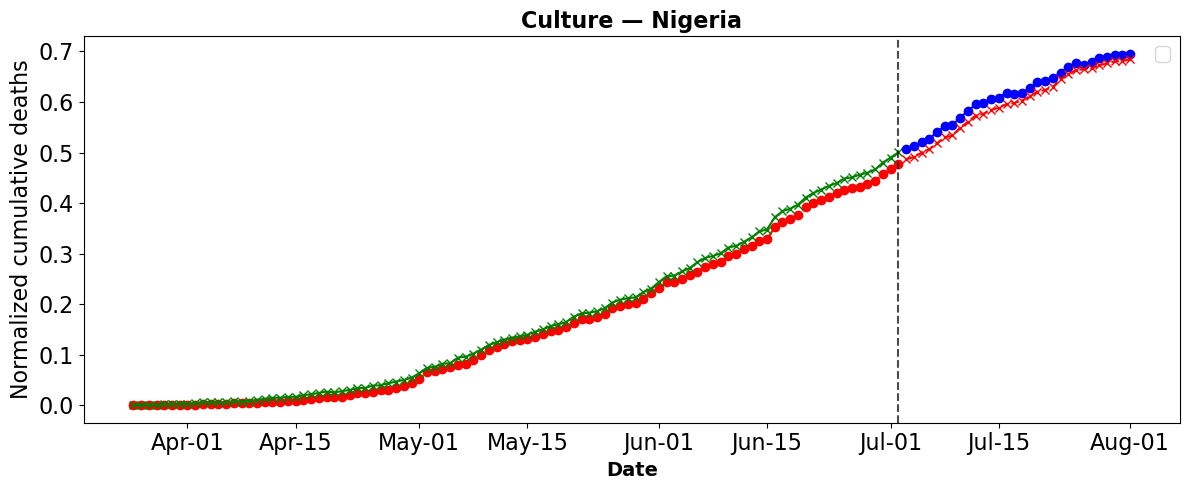

/tmp/ipykernel_15291/2841061231.py:308: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize = 14)


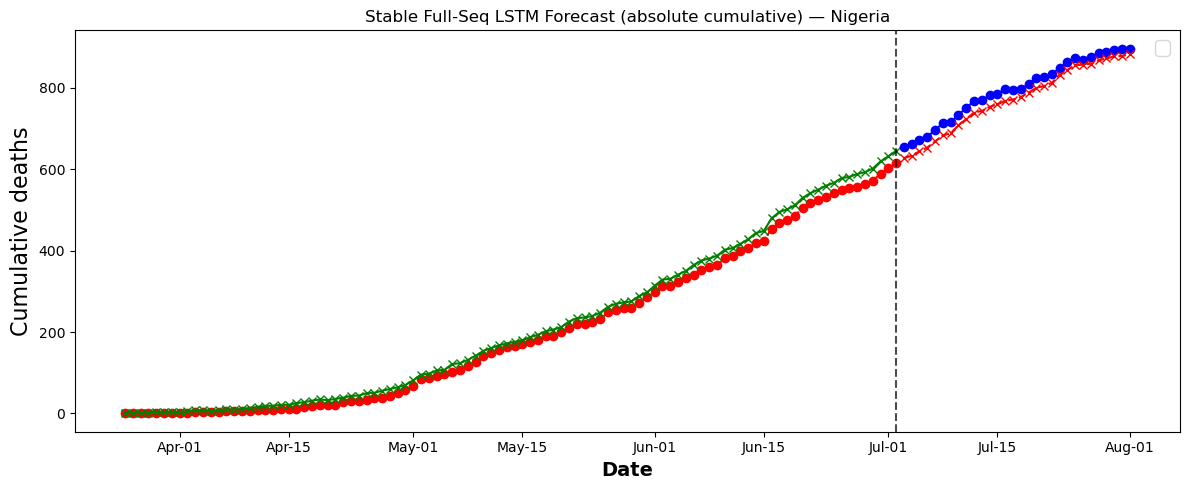

In [203]:
# final_stable_lstm_fullseq.py
# Single-file: preprocessing -> dataset -> model -> train -> forecast -> plot

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


                                                                                           # Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


                                                                                           # Hyperparameters

ENC_LEN = 100
FORECAST_LEN = 30
TOTAL_LEN = ENC_LEN + FORECAST_LEN
BATCH_SIZE = 32
EPOCHS = 2000
LR = 1e-3
HIDDEN = 128
NUM_LAYERS = 2
FORECAST_WEIGHT = 1.0                                                                  # weight for forecast MSE relative to train

                                                                                       # Load + rename (your file)

path = "Merged_1.csv"
df = pd.read_csv(path)

df = df.drop(['country_region', 'date.1'], axis=1, errors='ignore')
df = df.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'TotalDeaths',
    'date': 'Date',
    'individualism': 'Individualism',
    'masculinity': 'Masculinity',
    'powerdistance': 'Power Distance',
    'uncertaintyavoidance': 'Uncertainty Avoidance',
    'longtermorientation': 'Long Term Orientation',
    'democracyindex2021': 'Democracy Index',
    'indulgence': 'Indulgence',
    'gdp_per_capita': 'GDP (per capita)',
    'aged_65_older': 'Aged 65 Older',
    'stringency_index': 'Stringency Index',
    'population': 'Population'
})

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)


                                                            # Dynamic features: daily & cumulative (normalized by country max cumulative)

df['TotalDeaths'] = df['TotalDeaths'].fillna(0)
df['daily_deaths'] = df.groupby('Country')['TotalDeaths'].diff().fillna(0).clip(lower=0)
df['CumulativeDeaths'] = df.groupby('Country')['daily_deaths'].cumsum()

                                                                               # compute per-country scale (max cumulative); avoid zero
country_max = df.groupby('Country')['CumulativeDeaths'].transform('max').replace(0, 1.0)
df['cumulative_norm'] = df['CumulativeDeaths'] / country_max
df['daily_norm'] = df['daily_deaths'] / country_max


                                                                                    # Static features: Hofstede (standardize)
fixed_features = [
    'Individualism','Masculinity','Power Distance','Indulgence',
    'Uncertainty Avoidance','Long Term Orientation'
]
# ensure columns exist
for c in fixed_features:
    if c not in df.columns:
        df[c] = 0.0
# simple z-score over all countries (ok for static features)
df[fixed_features] = (df[fixed_features].fillna(0) - df[fixed_features].fillna(0).mean()) / (df[fixed_features].fillna(0).std() + 1e-9)


# Dataset: multi-country samples
# dynamic columns: we include daily_norm and cumulative_norm (D_dyn=2)
# target: cumulative_norm for TOTAL_LEN (we predict full cumulative_norm sequence directly)

dynamic_cols = ['daily_norm', 'cumulative_norm']   # D_dyn =We introduce a novel variational-LSTM Autoencoder model to predict the spread of coronavirus for each country across the globe. This deep Spatio-temporal model does not only rely on historical data of the virus spread but also includes factors related to urban characteristics represented in locational and demographic data (such as population density, urban population, and fertility rate), an index that represents the governmental measures and response amid toward mitigating the outbreak (includes 13 measures such as: 1) school closing, 2) workplace closing, 3) cancelling public events, 4) close public transport, 5) public information campaigns, 6) restrictions on internal movements, 7) international travel controls, 8) fiscal measures, 9) monetary measures, 10) emergency investment in health care, 11) investment in vaccines, 12) virus testing framework, and 13) contact tracing).  2
static_cols = fixed_features                       # S = 6

class CountryFullSeqDataset(Dataset):
    def __init__(self, df, dynamic_cols, static_cols, enc_len=ENC_LEN, forecast_len=FORECAST_LEN):
        self.enc_len = enc_len
        self.forecast_len = forecast_len
        self.total_len = enc_len + forecast_len
        self.dynamic_cols = dynamic_cols
        self.static_cols = static_cols
        self.samples = []

        for country, g in df.groupby('Country'):
            g = g.sort_values('Date').reset_index(drop=True)
            if len(g) >= self.total_len:
                dyn = g[self.dynamic_cols].values.astype(np.float32)  # [N, D_dyn]
                stat = g[self.static_cols].iloc[0].values.astype(np.float32)  # [S]
                target = g['cumulative_norm'].values.astype(np.float32)  # we predict cumulative_norm full sequence
                dates = g['Date'].values.copy()
                total_deaths = g['CumulativeDeaths'].values.copy()  # absolute cumulative
                # store
                self.samples.append({
                    'country': country,
                    'dyn': dyn,
                    'stat': stat,
                    'target': target,
                    'dates': dates,
                    'abs_cum': total_deaths
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        x_dyn = s['dyn'][:self.enc_len]                                                                         # [enc_len, D_dyn]
        x_stat = s['stat']                                                                                      # [S]
        y_full = s['target'][:self.total_len]                                                                   # [total_len]
        return torch.tensor(x_dyn), torch.tensor(x_stat), torch.tensor(y_full), s['country']


# Model: encode enc_len dynamics + static -> decode full TOTAL_LEN cumulative_norm
# Architecture:
#  - LSTM encoder on encoder window (input: dynamic features concatenated with static at each step)
#  - take last hidden (h_last)
#  - combine h_last + static MLP -> a vector z
#  - MLP decoder: maps z -> TOTAL_LEN outputs (cumulative_norm sequence)
# This is stable because prediction is produced in one pass (no autoregression).

class FullSeqLSTM(nn.Module):
    def __init__(self, dyn_dim, static_dim, hidden_dim=HIDDEN, num_layers=NUM_LAYERS, total_len=TOTAL_LEN):
        super().__init__()
        self.dyn_dim = dyn_dim
        self.static_dim = static_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.total_len = total_len

        # LSTM encoder
        self.lstm = nn.LSTM(input_size=dyn_dim + static_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True, bidirectional=False)

        # static encoder MLP
        self.static_mlp = nn.Sequential(
            nn.Linear(static_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # decoder MLP: map combined vector -> full TOTAL_LEN outputs
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.total_len),
        )

        # final output activation: cumulative_norm in [0,1] -> use sigmoid
        self.out_act = nn.Sigmoid()

    def forward(self, x_dyn, x_stat):
        # x_dyn: [B, T_enc, D_dyn]; x_stat: [B, S]
        B, T, D = x_dyn.shape
        # repeat static across time and concat
        stat_rep = x_stat.unsqueeze(1).repeat(1, T, 1)  # [B, T, S]
        lstm_in = torch.cat([x_dyn, stat_rep], dim=-1)  # [B, T, D_dyn + S]
        out, (h_n, c_n) = self.lstm(lstm_in)            # out: [B, T, hidden]
        h_last = h_n[-1]                                # [B, hidden]  (last layer)
        stat_enc = self.static_mlp(x_stat)              # [B, hidden]
        comb = torch.cat([h_last, stat_enc], dim=-1)    # [B, hidden*2]
        dec = self.decoder(comb)                        # [B, total_len]
        return self.out_act(dec)                        # in (0,1)


# Training utilities

def train_model(model, loader, epochs=EPOCHS, lr=LR, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device(device)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for ep in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for x_dyn, x_stat, y_full, _ in loader:
            x_dyn = x_dyn.to(device)                                                        # [B, enc_len, D_dyn]
            x_stat = x_stat.to(device)                                                        # [B, S]
            y_full = y_full.to(device)                                                   # [B, total_len]

            pred_full = model(x_dyn, x_stat)                                              # [B, total_len]
            # split train / forecast
            pred_train = pred_full[:, :ENC_LEN]
            pred_fore = pred_full[:, ENC_LEN:]
            y_train = y_full[:, :ENC_LEN]
            y_fore = y_full[:, ENC_LEN:]

            loss_train = loss_fn(pred_train, y_train)
            loss_fore = loss_fn(pred_fore, y_fore)
            loss = loss_train + FORECAST_WEIGHT * loss_fore

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            total_loss += loss.item()
        if ep % 25 == 0 or ep == 1:# Plot: normalized cumulative (so matches your older plots)


          print(f"Epoch {ep}/{epochs}  avg_loss={total_loss/len(loader):.6f}")
    return model

# -------------------------
# Instantiate dataset/model and train
# -------------------------
dataset = CountryFullSeqDataset(df, dynamic_cols=dynamic_cols, static_cols=static_cols,
                                enc_len=ENC_LEN, forecast_len=FORECAST_LEN)
if len(dataset) == 0:
    raise RuntimeError("No countries have enough length for ENC_LEN+FORECAST_LEN. Reduce ENC_LEN or FORECAST_LEN or check data.")
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

model = FullSeqLSTM(dyn_dim=len(dynamic_cols), static_dim=len(static_cols),
                    hidden_dim=HIDDEN, num_layers=NUM_LAYERS, total_len=TOTAL_LEN)

print("Dataset size (num countries trained):", len(dataset))
model = train_model(model, loader, epochs=EPOCHS, lr=LR)

# -------------------------
# Forecast & Plot for one country
# -------------------------
country_name = "Nigeria"   # change as needed
g = df[df['Country'] == country_name].sort_values('Date').reset_index(drop=True)

if len(g) < TOTAL_LEN:
    raise RuntimeError(f"{country_name} does not have >= {TOTAL_LEN} days; has {len(g)}")

# prepare inputs for this country
dyn_enc = torch.tensor(g[dynamic_cols].values[:ENC_LEN].astype(np.float32)).unsqueeze(0)  # [1, ENC_LEN, D_dyn]
stat_vec = torch.tensor(g[static_cols].iloc[0].values.astype(np.float32)).unsqueeze(0)   # [1, S]

model.eval()
with torch.no_grad():
    pred_full = model(dyn_enc, stat_vec).squeeze(0).cpu().numpy()  # [TOTAL_LEN] cumulative_norm

# split pred
pred_train_cum_norm = pred_full[:ENC_LEN]
pred_fore_cum_norm = pred_full[ENC_LEN:TOTAL_LEN]

# true sequences (cumulative_norm)
true_cum_norm = g['cumulative_norm'].values[:TOTAL_LEN]
true_train_cum_norm = true_cum_norm[:ENC_LEN]
true_fore_cum_norm = true_cum_norm[ENC_LEN:TOTAL_LEN]

# convert normalized cumulative -> absolute cumulative: multiply by country_max (we used that earlier)
country_scale_val = (g['CumulativeDeaths'].max() if g['CumulativeDeaths'].max() > 0 else 1.0)
true_train_abs = true_train_cum_norm * country_scale_val
true_fore_abs = true_fore_cum_norm * country_scale_val
pred_train_abs = pred_train_cum_norm * country_scale_val
pred_fore_abs = pred_fore_cum_norm * country_scale_val

# prepare plotting dates
dates = pd.to_datetime(g['Date'].iloc[:TOTAL_LEN])

# Plot: normalized cumulative (so matches your older plots)
plt.figure(figsize=(12,5))
plt.plot(dates[:ENC_LEN], true_train_cum_norm, 'o--', color='red')  #, label='True Train'
plt.plot(dates[:ENC_LEN], pred_train_cum_norm, 'x-', color='green')  #, label='Pred Train'
plt.plot(dates[ENC_LEN:TOTAL_LEN], pred_fore_cum_norm, 'o-', color='blue') #, label=f'Forecast ({FORECAST_LEN}d)'
plt.plot(dates[ENC_LEN:TOTAL_LEN], true_fore_cum_norm, 'x--', color='red')  #, label='True Future'
plt.axvline(dates[ENC_LEN-1], color='k', linestyle='--', alpha=0.7)
plt.title(f"Culture — {country_name}",fontsize=16,fontweight='bold') #Stable Full-Seq LSTM Forecast
plt.xlabel("Date", fontsize=14 ,fontweight='bold')
plt.ylabel("Normalized cumulative deaths",fontsize=16)
plt.legend(fontsize = 14)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Also plot absolute cumulative (optional)
plt.figure(figsize=(12,5))
plt.plot(dates[:ENC_LEN], true_train_abs, 'o--', color='red')  #, label='True Train (abs)'
plt.plot(dates[:ENC_LEN], pred_train_abs, 'x-', color='green')  #, label='Pred Train (abs)'
plt.plot(dates[ENC_LEN:TOTAL_LEN], pred_fore_abs, 'o-', color='blue') #, label=f'Forecast (abs {FORECAST_LEN}d)'
plt.plot(dates[ENC_LEN:TOTAL_LEN], true_fore_abs, 'x--', color='red') #, label='True Future (abs)'
plt.axvline(dates[ENC_LEN-1], color='k', linestyle='--', alpha=0.7)
plt.title(f"Stable Full-Seq LSTM Forecast (absolute cumulative) — {country_name}")
plt.xlabel("Date", fontsize=14 ,fontweight='bold')
plt.ylabel("Cumulative deaths",fontsize=16)
plt.legend(fontsize = 14)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
#plt.xticks(rotation=45)df_pred = pd.read_csv("predictions_Australia.csv")
#df_pred.head(20)
plt.tight_layout()
plt.show()


/tmp/ipykernel_15291/2827443400.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


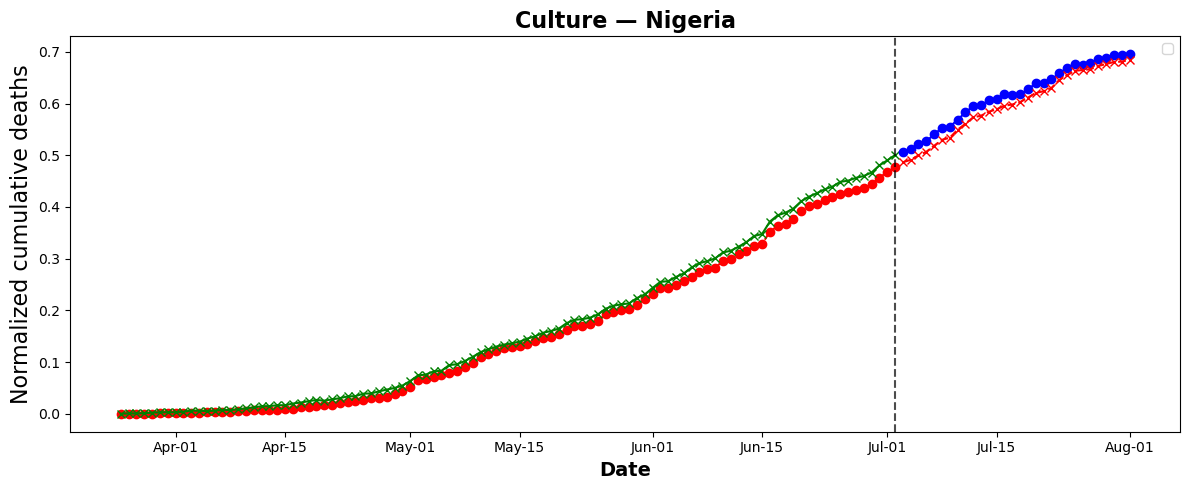

/tmp/ipykernel_15291/2827443400.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


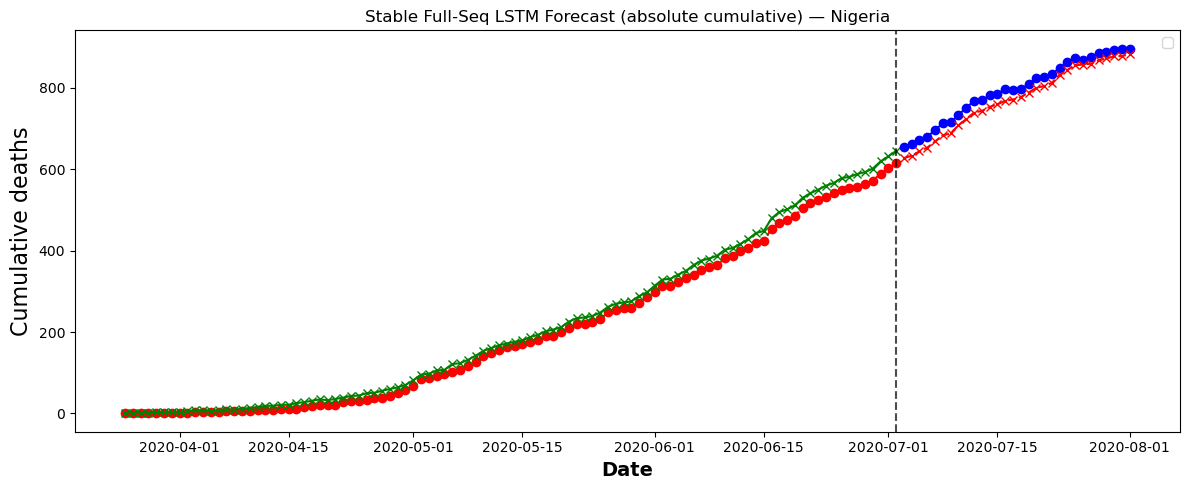

In [204]:
# Plot: normalized cumulative (so matches your older plots)
plt.figure(figsize=(12,5))
plt.plot(dates[:ENC_LEN], true_train_cum_norm, 'o--', color='red')  #, label='True Train'
plt.plot(dates[:ENC_LEN], pred_train_cum_norm, 'x-', color='green')  #, label='Pred Train'
plt.plot(dates[ENC_LEN:TOTAL_LEN], pred_fore_cum_norm, 'o-', color='blue') #, label=f'Forecast ({FORECAST_LEN}d)'
plt.plot(dates[ENC_LEN:TOTAL_LEN], true_fore_cum_norm, 'x--', color='red')  #, label='True Future'
plt.axvline(dates[ENC_LEN-1], color='k', linestyle='--', alpha=0.7)
plt.title(f"Culture — {country_name}",fontsize=16,fontweight ='bold') #Stable Full-Seq LSTM Forecast
plt.xlabel("Date", fontsize=14 ,fontweight='bold')
plt.ylabel("Normalized cumulative deaths",fontsize=16)
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Also plot absolute cumulative (optional)
plt.figure(figsize=(12,5))
plt.plot(dates[:ENC_LEN], true_train_abs, 'o--', color='red')  #, label='True Train (abs)'
plt.plot(dates[:ENC_LEN], pred_train_abs, 'x-', color='green')  #, label='Pred Train (abs)'
plt.plot(dates[ENC_LEN:TOTAL_LEN], pred_fore_abs, 'o-', color='blue') #, label=f'Forecast (abs {FORECAST_LEN}d)'
plt.plot(dates[ENC_LEN:TOTAL_LEN], true_fore_abs, 'x--', color='red') #, label='True Future (abs)'
plt.axvline(dates[ENC_LEN-1], color='k', linestyle='--', alpha=0.7)
plt.title(f"Stable Full-Seq LSTM Forecast (absolute cumulative) — {country_name}")
plt.xlabel("Date", fontsize=14 ,fontweight ='bold')
plt.ylabel("Cumulative deaths",fontsize=16)
plt.legend()
plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
#ax.tick_params(axis='x', labelsize=16) 
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [75]:
# -------------------------
# Save predictions to CSV
# -------------------------
out_df = pd.DataFrame({
    "Date": dates,
    "True_Cumulative_Normalized": np.concatenate([true_train_cum_norm, true_fore_cum_norm]),
    "Pred_Cumulative_Normalized": np.concatenate([pred_train_cum_norm, pred_fore_cum_norm]),
    "True_Cumulative_Absolute": np.concatenate([true_train_abs, true_fore_abs]),
    "Pred_Cumulative_Absolute": np.concatenate([pred_train_abs, pred_fore_abs]),
    "Split": ["Train"] * ENC_LEN + ["Forecast"] * FORECAST_LEN
})

out_path = f"predictions_cul_{country_name}.csv"
out_df.to_csv(out_path, index=False)

print(f"Saved predictions to: {out_path}")





Saved predictions to: predictions_cul_Nigeria.csv


In [76]:
df_pred = pd.read_csv("predictions_Chile.csv")
df_pred.head(20)


,Date,True_Cumulative_Normalized,Pred_Cumulative_Normalized,True_Cumulative_Absolute,Pred_Cumulative_Absolute,Split
0,2020-03-25,0.000000,0.000028,0.0,0.471630,Train
1,2020-03-26,0.000060,0.000090,1.0,1.499734,Train
2,2020-03-27,0.000120,0.000133,2.0,2.213716,Train
3,2020-03-28,0.000181,0.000159,3.0,2.636921,Train
4,2020-03-29,0.000241,0.000451,4.0,7.491785,Train
5,2020-03-30,0.000301,0.000452,5.0,7.497689,Train
6,2020-03-31,0.000542,0.000602,9.0,9.993991,Train
7,2020-04-01,0.000783,0.000402,13.0,6.668245,Train
8,2020-04-02,0.000903,0.000790,15.0,13.113163,Train
9,2020-04-03,0.001144,0.001719,19.0,28.544142,Train


In [241]:
countries = df['Country'].unique()
np.random.shuffle(countries)

split = int(0.8 * len(countries))
train_countries = countries[:split]
test_countries  = countries[split:]

train_df = df[df['Country'].isin(train_countries)]
test_df  = df[df['Country'].isin(test_countries)]


In [80]:
# ------------------------------------
# Train / Test split by country
# ------------------------------------
countries = df['Country'].unique()
np.random.seed(42)
np.random.shuffle(countries)

split = int(0.8 * len(countries))
train_countries = countries[:split]
test_countries  = countries[split:]

train_df = df[df['Country'].isin(train_countries)]
test_df  = df[df['Country'].isin(test_countries)]


In [81]:
train_dataset = CountryFullSeqDataset(
    train_df,
    dynamic_cols=dynamic_cols,
    static_cols=static_cols,
    enc_len=ENC_LEN,
    forecast_len=FORECAST_LEN
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

model = train_model(model, train_loader)


Epoch 1/2000  avg_loss=0.001970
Epoch 25/2000  avg_loss=0.000033
Epoch 50/2000  avg_loss=0.000017
Epoch 75/2000  avg_loss=0.000013
Epoch 100/2000  avg_loss=0.000011
Epoch 125/2000  avg_loss=0.000010
Epoch 150/2000  avg_loss=0.000010
Epoch 175/2000  avg_loss=0.000009
Epoch 200/2000  avg_loss=0.000010
Epoch 225/2000  avg_loss=0.000011
Epoch 250/2000  avg_loss=0.000116
Epoch 275/2000  avg_loss=0.000066
Epoch 300/2000  avg_loss=0.000028
Epoch 325/2000  avg_loss=0.000012
Epoch 350/2000  avg_loss=0.000012
Epoch 375/2000  avg_loss=0.000057
Epoch 400/2000  avg_loss=0.002138
Epoch 425/2000  avg_loss=0.000043
Epoch 450/2000  avg_loss=0.000018
Epoch 475/2000  avg_loss=0.000011
Epoch 500/2000  avg_loss=0.000009
Epoch 525/2000  avg_loss=0.000008
Epoch 550/2000  avg_loss=0.000007
Epoch 575/2000  avg_loss=0.000006
Epoch 600/2000  avg_loss=0.000006
Epoch 625/2000  avg_loss=0.000006
Epoch 650/2000  avg_loss=0.000006
Epoch 675/2000  avg_loss=0.000005
Epoch 700/2000  avg_loss=0.000005
Epoch 725/2000  avg

In [82]:
def compute_test_mse(model, test_df):
    model.eval()
    device = next(model.parameters()).device

    squared_errors = []

    with torch.no_grad():
        for country, g in test_df.groupby('Country'):

            g = g.sort_values('Date').reset_index(drop=True)
            if len(g) < TOTAL_LEN:
                continue

            # Encoder input
            x_dyn = torch.tensor(
                g[dynamic_cols].values[:ENC_LEN],
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            x_stat = torch.tensor(
                g[static_cols].iloc[0].values,
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            # True future (TEST)
            y_true = g['cumulative_norm'].values[ENC_LEN:TOTAL_LEN]

            # Prediction
            y_pred = model(x_dyn, x_stat).cpu().numpy()[0, ENC_LEN:TOTAL_LEN]

            squared_errors.extend((y_pred - y_true) ** 2)

    test_mse = np.mean(squared_errors)
    return test_mse


In [83]:
test_mse = compute_test_mse(model, test_df)
print(f"TEST MSE (forecast horizon): {test_mse:.6f}")


TEST MSE (forecast horizon): 0.000730


Compute RMSE + MAE for all countries

Create Country-Level Train/Val Split

In [84]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch

# df contains all countries combined
countries = df["Country"].unique()
np.random.seed(42)

# 70/15/15 split
np.random.shuffle(countries)

train_c = countries[:70]
val_c = countries[70:80]
test_c = countries[80:]


Filter the datasets

Use the SAME dataset class for train & val


Modify Training Function to Compute Validation Loss

In [85]:
def train_model(model, train_loader, val_loader, epochs=1000, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = torch.nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            output = model(X)

            loss = mse(output[:, 100:], y[:, 100:])   # Only forecast window
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # --------------------------
        # VALIDATION LOSS
        # --------------------------
        model.eval()
        val_losses = []

        with torch.no_grad():
            for X, y in val_loader:
                X = X.to(device)
                y = y.to(device)

                output = model(X)
                val_loss = mse(output[:, 100:], y[:, 100:])
                val_losses.append(val_loss.item())

        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Train Loss={np.mean(train_losses):.5f}, Val Loss={np.mean(val_losses):.5f}")
